In [1]:
from __future__ import absolute_import
from __future__  import division
from __future__ import print_function
import tensorflow as tf
import numpy as np
from skimage.io import imread
from skimage.transform import resize
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import os

In [4]:
fights_train = np.zeros((700, 40, 160, 160, 3), dtype=np.float32)
labels_train = []

In [8]:
import os
import cv2
import numpy as np
from skimage.transform import resize
from sklearn.model_selection import train_test_split

def capture(filename):
    frames = np.zeros((40, 160, 160, 3), dtype=np.float32)
    i = 0
    vc = cv2.VideoCapture(filename)
    if vc.isOpened():
        rval, frame = vc.read()
    else:
        rval = False
    
    while rval and i < 40:
        frm = resize(frame, (160, 160, 3))
        frm = np.expand_dims(frm, axis=0)
        if np.max(frm) > 1:
            frm = frm / 255.0
        frames[i][:] = frm
        i += 1
        rval, frame = vc.read()
    
    vc.release()
    return frames

def cut_save(main_dir='./trainm/', mod='train', batch_size=10):
    fights_train_list = []
    labels_train_list = []
    
    def construct_video_path(main_dir, video_file):
        return os.path.join(main_dir, video_file)
    
    # Create main directory if it doesn't exist
    if not os.path.exists(main_dir):
        os.makedirs(main_dir)
    
    try:
        # Iterate through video files in the directory
        for file in os.listdir(main_dir):
            full_video_path = construct_video_path(main_dir, file)  # Full path to video file
            videos = capture(full_video_path)  # Assuming capture() function reads video frames
            
            fights_train_list.append(videos)
            labels_train_list.append(1)  # Assuming all videos in this directory are 'fights'
            
            # Yield batches of data
            if len(fights_train_list) == batch_size:
                yield np.array(fights_train_list), np.array(labels_train_list)
                fights_train_list = []
                labels_train_list = []
                        
    except FileNotFoundError:
        print(f"Directory '{main_dir}' does not exist.")
    except PermissionError:
        print(f"Permission denied to access directory '{main_dir}'.")
    except Exception as e:
        print(f"Error occurred: {e}")
    
    # Yield remaining data
    if len(fights_train_list) > 0:
        yield np.array(fights_train_list), np.array(labels_train_list)

# Example usage:
batch_size = 10
generator = cut_save(main_dir=r'C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight', batch_size=batch_size)

# Collect and split data in batches to avoid memory issues
all_fights_train = []
all_labels_train = []
for fights_data, labels_data in generator:
    all_fights_train.extend(fights_data)
    all_labels_train.extend(labels_data)

# Convert lists to numpy arrays
all_fights_train = np.array(all_fights_train)
all_labels_train = np.array(all_labels_train)

# Print sizes before train_test_split to debug
print(f"Total fights_train size: {len(all_fights_train)}, Total labels_train size: {len(all_labels_train)}")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(all_fights_train, all_labels_train, test_size=0.33, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Total fights_train size: 14, Total labels_train size: 14
X_train shape: (9, 40, 160, 160, 3), y_train shape: (9,)
X_test shape: (5, 40, 160, 160, 3), y_test shape: (5,)


In [9]:
cut_save('./trainm/',"train")

<generator object cut_save at 0x0000019B0197F350>

In [10]:
all_fights_train.shape

(14, 40, 160, 160, 3)

In [11]:

from sklearn.model_selection import train_test_split

In [12]:

X_train, X_test, y_train, y_test = train_test_split(all_fights_train, all_labels_train, test_size=0.33, random_state=42)


In [13]:
fights_train = []

In [14]:

import numpy as np

# Reduce array size and use np.float32 instead of np.float64
fights_test = np.zeros((100, 40, 160, 160, 3), dtype=np.float32)
labels_test = []

# Example: Print memory usage information
print("Memory usage for fights_test:", fights_test.nbytes / (1024 * 1024), "MB")

# Proceed with your data processing or model evaluation


Memory usage for fights_test: 1171.875 MB


In [15]:
cut_save('./testm/',"test")

<generator object cut_save at 0x0000019B0197F480>

In [16]:
# Print the type and length of fights_train
print(f"Type of fights_train: {type(fights_train)}")
print(f"Length of fights_train: {len(fights_train)}")

# If it's a list, print the type and length of its first element
if isinstance(fights_train, list) and len(fights_train) > 0:
    print(f"Type of fights_train[0]: {type(fights_train[0])}")
    print(f"Length of fights_train[0]: {len(fights_train[0])}")

# If it's a numpy array, print its shape
if isinstance(fights_train, np.ndarray):
    print(f"Shape of fights_train: {fights_train.shape}")


Type of fights_train: <class 'list'>
Length of fights_train: 0


Captured 40 frames from C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight\NV_992.mp4
Captured 40 frames from C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight\NV_993.mp4
Captured 40 frames from C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight\NV_994.mp4
Captured 40 frames from C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight\NV_995.mp4
Captured 40 frames from C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight\NV_996.mp4
Captured 40 frames from C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight\NV_997.mp4
Captured 40 frames from C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight\NV_998.mp4
Captured 40 frames from C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight\V_982.mp4
Captured 40 frames from C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight\V_98

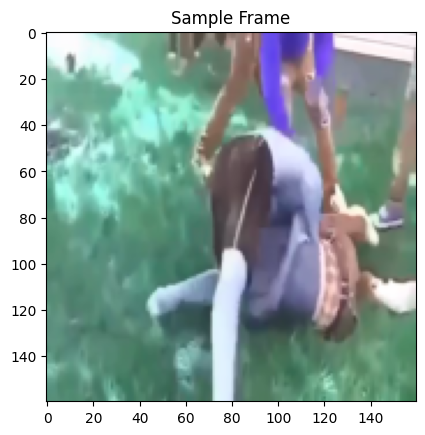

In [18]:
import os
import cv2
import numpy as np
from skimage.transform import resize
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def capture(filename):
    frames = np.zeros((40, 160, 160, 3), dtype=np.float32)
    i = 0
    vc = cv2.VideoCapture(filename)
    
    if vc.isOpened():
        rval, frame = vc.read()
        if not rval:
            print(f"Failed to read frame from {filename}")
            return frames
        
        while rval and i < 40:
            if frame is None:
                print(f"Frame is None at index {i} in video {filename}")
                rval = False
                continue
            
            frm = resize(frame, (160, 160, 3))
            frm = np.expand_dims(frm, axis=0)
            
            if np.max(frm) > 1:
                frm = frm / 255.0
            
            frames[i][:] = frm
            i += 1
            rval, frame = vc.read()
        
        vc.release()
        print(f"Captured {i} frames from {filename}")
    else:
        print(f"Unable to open video file {filename}")
    
    return frames

def cut_save(main_dir='./trainm/', mod='train', batch_size=10):
    fights_train_list = []
    labels_train_list = []
    
    def construct_video_path(main_dir, video_file):
        return os.path.join(main_dir, video_file)
    
    if not os.path.exists(main_dir):
        os.makedirs(main_dir)
    
    try:
        for file in os.listdir(main_dir):
            full_video_path = construct_video_path(main_dir, file)
            videos = capture(full_video_path)
            
            if videos.size == 0:
                print(f"No frames captured from {full_video_path}")
                continue
            
            fights_train_list.append(videos)
            labels_train_list.append(1)  # Assuming all videos in this directory are 'fights'
            
            if len(fights_train_list) == batch_size:
                yield np.array(fights_train_list), np.array(labels_train_list)
                fights_train_list = []
                labels_train_list = []
                        
    except FileNotFoundError:
        print(f"Directory '{main_dir}' does not exist.")
    except PermissionError:
        print(f"Permission denied to access directory '{main_dir}'.")
    except Exception as e:
        print(f"Error occurred: {e}")
    
    if len(fights_train_list) > 0:
        yield np.array(fights_train_list), np.array(labels_train_list)

def visualize_frame(frame):
    plt.imshow(frame)
    plt.title("Sample Frame")
    plt.show()

# Example usage:
batch_size = 10
generator = cut_save(main_dir=r'C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight', batch_size=batch_size)

all_fights_train = []
all_labels_train = []

for fights_data, labels_data in generator:
    all_fights_train.extend(fights_data)
    all_labels_train.extend(labels_data)

# Convert lists to numpy arrays
all_fights_train = np.array(all_fights_train)
all_labels_train = np.array(all_labels_train)

print(f"Total fights_train size: {len(all_fights_train)}, Total labels_train size: {len(all_labels_train)}")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(all_fights_train, all_labels_train, test_size=0.33, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Check the min and max values of a sample frame
sample_frame = X_test[0][0]  # Example: first video, first frame
print(f"Sample frame min value: {np.min(sample_frame)}, Max value: {np.max(sample_frame)}")

# Visualize the sample frame
visualize_frame(sample_frame)


In [15]:
import tensorflow
layers = tensorflow.keras.layers
models = tensorflow.keras.models
losses = tensorflow.keras.losses
optimizers = tensorflow.keras.optimizers 
metrics = tensorflow.keras.metrics
utils = tensorflow.keras.utils
callbacks = tensorflow.keras.callbacks
layers = tensorflow.keras.layers
models = tensorflow.keras.models
ImageDataGenerator = tensorflow.keras.preprocessing.image.ImageDataGenerator
losses = tensorflow.keras.losses
optimizers = tensorflow.keras.optimizers 
metrics = tensorflow.keras.metrics
utils = tensorflow.keras.utils
callbacks = tensorflow.keras.callbacks

plot_model = tensorflow.keras.utils.plot_model

In [16]:
np.random.seed(1234)
num_classes = 2

In [18]:
np.random.seed(1234)
num_classes = 2
vg19 = tensorflow.keras.applications.vgg19.VGG19
base_model = vg19(include_top=False,weights='imagenet',input_shape=(160, 160,3))
# Freeze the layers except the last 4 layers
for layer in base_model.layers:
    layer.trainable = False
# Check the trainable status of the individual layers
base_model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 160, 160, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 160, 160, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 80, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 80, 80, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 40, 40, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 40, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 40, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 40, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 20, 20, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 20, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 20, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 20, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 10, 10, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

In [19]:
from keras import models, layers, optimizers
from keras.applications import VGG16  # Example base model, replace with your choice

num_classes = 2

# Define your convolutional base model (example using VGG16)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(160, 160, 3))

# Freeze convolutional layers if needed
for layer in base_model.layers:
    layer.trainable = False

# Create the LSTM model on top of the convolutional base
model = models.Sequential()

cnn = models.Sequential()
cnn.add(base_model)
cnn.add(layers.Flatten())

model.add(layers.TimeDistributed(cnn, input_shape=(40, 160, 160, 3)))
model.add(layers.LSTM(40, return_sequences=True))
model.add(layers.TimeDistributed(layers.Dense(160, activation='relu')))
model.add(layers.GlobalAveragePooling1D(name="global_average_pooling"))

model.add(layers.Dense(num_classes, activation="sigmoid", name="output"))

# Compile the model
adam = optimizers.Adam(learning_rate=0.0005, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=["accuracy"])

model.summary()


c:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\myenv\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 40, 12800)      │    14,714,688 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 40, 40)         │     2,054,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 40, 160)        │         6,560 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 160)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,776,130 (64.00 MB)

 Trainable params: 2,061,442 (7.86 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:

class AccuracyHistory(callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.acc = []
        self.val_acc = []
        self.loss = []
        self.val_loss = []

    def on_epoch_end(self, batch, logs={}):
        self.acc.append(logs.get('acc'))
        self.val_acc.append(logs.get('val_acc'))
        self.loss.append(logs.get('loss'))
        self.val_loss.append(logs.get('val_loss'))

history = AccuracyHistory()
earlyStopping = callbacks.EarlyStopping(monitor='val_loss', patience=8,min_delta=1e-5, verbose=0, mode='min')
mcp_save = callbacks.ModelCheckpoint('mamon98777.keras', save_best_only=True, monitor='val_loss', mode='min')
reduce_lr_loss = callbacks.ReduceLROnPlateau(monitor='val_loss',patience=1, verbose=2,factor=0.5,min_lr=0.0000001)


In [21]:
batch_size =3
epochs = 10

In [23]:
import numpy as np
from keras.utils import to_categorical

# Example data (replace with your actual data loading code)
labels_train = np.array([0, 1, 0, 2, 1])  # Example labels array

# Check the shape and content of labels_train
print("Shape of labels_train:", labels_train.shape)
print("Unique labels in labels_train:", np.unique(labels_train))

# Convert labels_train to categorical format
try:
    y_train = to_categorical(labels_train)
    print("Categorical labels (y_train):\n", y_train)
except ValueError as e:
    print("ValueError:", e)


Shape of labels_train: (5,)
Unique labels in labels_train: [0 1 2]
Categorical labels (y_train):
 [[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [24]:
y_train = utils.to_categorical(labels_train)
print(y_train)

[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [25]:
y_test = utils.to_categorical(labels_train)
print(y_test)

[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [71]:
import time
import numpy as np

millis = int(round(time.time() * 1000))
print("Started at", millis)

# Example: Assuming fights_train is already populated
fights_train = np.zeros((500, 40, 160, 160, 3), dtype=np.float32)  # Adjusted size for example
# Example: Assuming labels_train is populated accordingly
labels_train = np.random.randint(0, 2, size=(500,))  # Example: Random labels, adjust based on your actual labels

# Verify shapes
print("Shapes:")
print("fights_train:", fights_train.shape)
print("labels_train:", labels_train.shape)

# Initialize y_train based on labels_train
y_train = np.zeros((len(labels_train), 2))  # Adjust 2 based on your number of classes
for i, label in enumerate(labels_train):
    y_train[i, label] = 1

# Example of fitting the model (adjust parameters as needed)
try:
    model.fit(fights_train, y_train,
              batch_size=batch_size,
              epochs=epochs,
              verbose=1,
              validation_split=0.2,  # Adjust validation split if needed
              callbacks=[earlyStopping, mcp_save, reduce_lr_loss, history])
except Exception as e:
    print("Error during model fitting:", e)


Started at 1720602616317
Shapes:
fights_train: (500, 40, 160, 160, 3)
labels_train: (500,)
Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 1990s 14s/step - accuracy: 0.4752 - loss: 0.7060 - val_accuracy: 0.4900 - val_loss: 0.6945 - learning_rate: 5.0000e-04
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 1746s 13s/step - accuracy: 0.4286 - loss: 0.6973 - val_accuracy: 0.5100 - val_loss: 0.6931 - learning_rate: 5.0000e-04
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5349 - loss: 0.6935
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
134/134 ━━━━━━━━━━━━━━━━━━━━ 1629s 12s/step - accuracy: 0.5348 - loss: 0.6935 - val_accuracy: 0.4900 - val_loss: 0.6957 - learning_rate: 5.0000e-04
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4561 - loss: 0.6996
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
134/134 ━━━━━━━━━━━━━━━━━━━━ 1673s 13s/step - accuracy: 0.4567 - loss: 0.6995 - val_accuracy: 0.4900 - val_loss: 0.6979

In [26]:
fights_test = []

In [1]:
import os
import numpy as np
import cv2
from skimage.transform import resize
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import random


In [2]:
class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, videos, labels, batch_size=4, shuffle=True):
        self.videos = videos
        self.labels = labels.reshape(-1, 1)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.videos))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.videos) / float(self.batch_size)))
    
    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_videos = self.videos[batch_indices]
        batch_labels = self.labels[batch_indices]
        print(f"Fetching batch {index}, shape: {batch_videos.shape}")
        return batch_videos, batch_labels
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)
        print("Epoch ended, indices shuffled")


In [3]:
def capture(filename, num_frames=40, frame_size=(160, 160)):
    try:
        frames = np.zeros((num_frames, *frame_size, 3), dtype=np.float32)
        vc = cv2.VideoCapture(filename)
        i = 0
        while i < num_frames:
            rval, frame = vc.read()
            if not rval:
                break
            frm = resize(frame, frame_size, mode='reflect')
            frm = frm / 255.0
            frames[i] = frm
            i += 1
        vc.release()
        return frames
    except Exception as e:
        print(f"Error processing file {filename}: {str(e)}")
        return None


In [4]:
def load_videos(main_dir, batch_size=4):
    fights_train_list = []
    labels_train_list = []
    
    for file in os.listdir(main_dir):
        full_video_path = os.path.join(main_dir, file)
        videos = capture(full_video_path)
        if videos is not None:
            fights_train_list.append(videos)
            labels_train_list.append(1)  # Assuming all videos in this directory are 'fights'
        
        if len(fights_train_list) == batch_size:
            yield np.array(fights_train_list), np.array(labels_train_list).reshape(-1, 1)
            fights_train_list = []
            labels_train_list = []
    
    if len(fights_train_list) > 0:
        yield np.array(fights_train_list), np.array(labels_train_list).reshape(-1, 1)


In [5]:
main_dir = r'C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight'
batch_size = 4
generator = load_videos(main_dir, batch_size=batch_size)

all_fights_train = []
all_labels_train = []
for fights_data, labels_data in generator:
    all_fights_train.extend(fights_data)
    all_labels_train.extend(labels_data)

all_fights_train = np.array(all_fights_train)
all_labels_train = np.array(all_labels_train).reshape(-1, 1)

print(f"Total videos: {all_fights_train.shape[0]}")
print(f"Labels shape: {all_labels_train.shape}")


Total videos: 14
Labels shape: (14, 1)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(all_fights_train, all_labels_train, test_size=0.33, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (9, 40, 160, 160, 3), y_train shape: (9, 1)
X_test shape: (5, 40, 160, 160, 3), y_test shape: (5, 1)


In [7]:
def create_model(input_shape):
    model = models.Sequential([
        layers.Conv3D(32, (3, 3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling3D((2, 2, 2)),
        layers.Conv3D(64, (3, 3, 3), activation='relu'),
        layers.MaxPooling3D((2, 2, 2)),
        layers.Conv3D(128, (3, 3, 3), activation='relu'),
        layers.MaxPooling3D((2, 2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [8]:
input_shape = (40, 160, 160, 3)  # (time_steps, height, width, channels)
model = create_model(input_shape)


c:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
train_generator = VideoDataGenerator(X_train, y_train, batch_size=batch_size)
test_generator = VideoDataGenerator(X_test, y_test, batch_size=batch_size)

print(f"Total training samples: {len(X_train)}")
print(f"Total validation samples: {len(X_test)}")
print(f"Number of training batches: {len(train_generator)}")
print(f"Number of validation batches: {len(test_generator)}")


Epoch ended, indices shuffled
Epoch ended, indices shuffled
Total training samples: 9
Total validation samples: 5
Number of training batches: 3
Number of validation batches: 2


In [10]:
first_batch = train_generator[0]
if first_batch[0] is not None and first_batch[1] is not None:
    print(f"First batch X shape: {first_batch[0].shape}")
    print(f"First batch y shape: {first_batch[1].shape}")
else:
    print("First batch contains None values")


Fetching batch 0, shape: (4, 40, 160, 160, 3)
First batch X shape: (4, 40, 160, 160, 3)
First batch y shape: (4, 1)


In [11]:
num_epochs = 10
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    # Training
    train_loss = 0
    train_accuracy = 0
    for batch_idx in range(len(train_generator)):
        x_batch, y_batch = train_generator[batch_idx]
        if x_batch is None or y_batch is None:
            print(f"Skipping batch {batch_idx} due to None values")
            continue
        loss, accuracy = model.train_on_batch(x_batch, y_batch)
        train_loss += loss
        train_accuracy += accuracy
        print(f"Batch {batch_idx+1}/{len(train_generator)}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
    
    train_loss /= len(train_generator)
    train_accuracy /= len(train_generator)
    
    # Validation
    val_loss = 0
    val_accuracy = 0
    for batch_idx in range(len(test_generator)):
        x_batch, y_batch = test_generator[batch_idx]
        if x_batch is None or y_batch is None:
            print(f"Skipping validation batch {batch_idx} due to None values")
            continue
        loss, accuracy = model.test_on_batch(x_batch, y_batch)
        val_loss += loss
        val_accuracy += accuracy
    
    val_loss /= len(test_generator)
    val_accuracy /= len(test_generator)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")


Epoch 1/10
Fetching batch 0, shape: (4, 40, 160, 160, 3)
Batch 1/3, Loss: 0.6932, Accuracy: 0.0000
Fetching batch 1, shape: (4, 40, 160, 160, 3)
Batch 2/3, Loss: 0.6514, Accuracy: 0.5000
Fetching batch 2, shape: (1, 40, 160, 160, 3)
Batch 3/3, Loss: 0.6090, Accuracy: 0.5556
Fetching batch 0, shape: (4, 40, 160, 160, 3)
Fetching batch 1, shape: (1, 40, 160, 160, 3)
Epoch 1/10
Train Loss: 0.6512, Train Accuracy: 0.3519
Val Loss: 0.4103, Val Accuracy: 0.7033
Epoch 2/10
Fetching batch 0, shape: (4, 40, 160, 160, 3)
Batch 1/3, Loss: 0.3105, Accuracy: 0.7778
Fetching batch 1, shape: (4, 40, 160, 160, 3)
Batch 2/3, Loss: 0.2541, Accuracy: 0.8182
Fetching batch 2, shape: (1, 40, 160, 160, 3)
Batch 3/3, Loss: 0.2430, Accuracy: 0.8261
Fetching batch 0, shape: (4, 40, 160, 160, 3)
Fetching batch 1, shape: (1, 40, 160, 160, 3)
Epoch 2/10
Train Loss: 0.2692, Train Accuracy: 0.8073
Val Loss: 0.2033, Val Accuracy: 0.8545
Epoch 3/10
Fetching batch 0, shape: (4, 40, 160, 160, 3)
Batch 1/3, Loss: 0.1747

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
def show_sample_frames(frames, labels, num_samples=5):
    for _ in range(num_samples):
        idx = random.randint(0, len(frames) - 1)
        sample_frames = frames[idx]
        label = labels[idx]
        
        fig, axes = plt.subplots(1, len(sample_frames), figsize=(15, 5))
        for i, frame in enumerate(sample_frames):
            axes[i].imshow(frame)
            axes[i].axis('off')
        plt.suptitle(f'Label: {label[0]}')  # Access the label value
        plt.show()

show_sample_frames(X_train, y_train)


In [9]:
fights_train = []

In [10]:
import os
import cv2
import numpy as np
from skimage.transform import resize
from sklearn.model_selection import train_test_split

def capture(filename):
    frames = np.zeros((40, 160, 160, 3), dtype=np.float64)
    i = 0
    vc = cv2.VideoCapture(filename)
    if vc.isOpened():
        rval, frame = vc.read()
    else:
        rval = False

    frm = resize(frame, (160, 160, 3))
    frm = np.expand_dims(frm, axis=0)
    if np.max(frm) > 1:
        frm = frm / 255.0
    frames[i][:] = frm
    i += 1

    while i < 40:
        rval, frame = vc.read()
        frm = resize(frame, (160, 160, 3))
        frm = np.expand_dims(frm, axis=0)
        if np.max(frm) > 1:
            frm = frm / 255.0
        frames[i][:] = frm
        i += 1

    return frames

def cut_save(main_dir='./trainm/', mod='train', batch_size=10):
    fights_train_list = []
    labels_train_list = []

    def construct_video_path(main_dir, video_file):
        return os.path.join(main_dir, video_file)

    # Create main directory if it doesn't exist
    if not os.path.exists(main_dir):
        os.makedirs(main_dir)

    try:
        # Iterate through fight_videos directory
        for file in os.listdir(main_dir):
            full_video_path = construct_video_path(main_dir, file)  # Full path to video file
            videos = capture(full_video_path)  # Assuming capture() function reads video frames

            fights_train_list.append(videos)
            labels_train_list.append(1)  # Assuming all videos in this directory are 'fights'

            # Batch processing: process in batches of batch_size
            if len(fights_train_list) == batch_size:
                yield np.array(fights_train_list), np.array(labels_train_list)
                fights_train_list = []
                labels_train_list = []

    except FileNotFoundError:
        print(f"Directory '{main_dir}' does not exist.")
    except PermissionError:
        print(f"Permission denied to access directory '{main_dir}'.")
    except Exception as e:
        print(f"Error occurred: {e}")

    # Yield remaining batches
    if len(fights_train_list) > 0:
        yield np.array(fights_train_list), np.array(labels_train_list)

# Example usage:
batch_size = 10
generator = cut_save(main_dir=r'C:\Users\91879\Downloads\Real-Time-Violence-Detection-in-Video-\videos_fight', batch_size=batch_size)

# Collect all batches into a single dataset
all_fights_train = []
all_labels_train = []
for fights_data, labels_data in generator:
    all_fights_train.extend(fights_data)
    all_labels_train.extend(labels_data)

# Convert lists to numpy arrays
all_fights_train = np.array(all_fights_train)
all_labels_train = np.array(all_labels_train)

# Print sizes before train_test_split to debug
print(f"Total fights_train size: {len(all_fights_train)}, Total labels_train size: {len(all_labels_train)}")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(all_fights_train, all_labels_train, test_size=0.33, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Assuming 'model' is already defined and compiled
model = model = models.Sequential()

# Evaluate the model on the test set
try:
    score = model.evaluate(X_test, y_test, batch_size=3)
    print("Evaluation score:", score)
except Exception as e:
    print("Exception:", e)


Total fights_train size: 14, Total labels_train size: 14
X_train shape: (9, 40, 160, 160, 3), y_train shape: (9,)
X_test shape: (5, 40, 160, 160, 3), y_test shape: (5,)


NameError: name 'models' is not defined

In [11]:
import numpy as np
from keras.utils import to_categorical

# Reduce array size and use np.float32 instead of np.float64
fights_test = np.zeros((100, 40, 160, 160, 3), dtype=np.float32)
labels_test = np.random.randint(0, 2, size=(100,))  # Example labels, replace with actual labels

# Convert labels to categorical format
labels_test = to_categorical(labels_test, num_classes=2)

# Example: Print memory usage information
print("Memory usage for fights_test:", fights_test.nbytes / (1024 * 1024), "MB")
print("fights_test shape:", fights_test.shape)
print("labels_test shape:", labels_test.shape)

# Model evaluation
try:
    score = model.evaluate(fights_test, labels_test, batch_size=3)
    print("Evaluation score:", score)
except Exception as e:
    print("Exception during model evaluation:", e)


Memory usage for fights_test: 1171.875 MB
fights_test shape: (100, 40, 160, 160, 3)
labels_test shape: (100, 2)
Exception during model evaluation: name 'model' is not defined


In [39]:
score = model.evaluate(fights_test, y_test, batch_size=3)
score

NameError: name 'model' is not defined

In [90]:
from sklearn.metrics import classification_report, confusion_matrix


In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def print_confusion_matrix(confusion_matrix, class_names, figsize = (10,7), fontsize=14):
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names, 
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    return fig

In [93]:
Y_pred = model.predict(fights_test , batch_size=1)

100/100 ━━━━━━━━━━━━━━━━━━━━ 981s 9s/step


In [94]:
yprd = Y_pred > 0.5
yprd

array([[False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [False,  True],
       [Fal

In [95]:
ypredicted = []
for zero,one in yprd:
    if zero == True:
        ypredicted.append(0)
    else:
        ypredicted.append(1) 

In [96]:
ypredicted

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [97]:
y_test

array([[0., 1.],
       [0., 1.],
       [0., 1.]])

In [98]:
y = []

for zero,one in y_test:
    if zero == True:
        y.append(0)
    else:
        y.append(1) 

In [105]:
confusion = confusion_matrix(y,ypredicted)
confusion.shape

ValueError: Found input variables with inconsistent numbers of samples: [3, 100]

In [107]:
print_confusion_matrix(confusion, [0,1], figsize = (30,15), fontsize=16)

NameError: name 'confusion' is not defined

In [12]:
print('Classification Report')
print(classification_report(y, ypredicted, target_names=['no-violance','violance']))

Classification Report


NameError: name 'classification_report' is not defined

In [109]:
model.save("mamonbest980hocky.hdfs")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=mamonbest980hocky.hdfs.